In [0]:
dbutils.widgets.text("catalog", "fiap_analytics")
dbutils.widgets.text("schema_ml", "ml")

CATALOG   = dbutils.widgets.get("catalog")
SCHEMA_ML = dbutils.widgets.get("schema_ml")
G  = f"{CATALOG}.gold"
ML = f"{CATALOG}.{SCHEMA_ML}"

spark.sql(f"CREATE SCHEMA IF NOT EXISTS {ML}")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

print(f"Schema ML: {ML}")

Schema ML: fiap_analytics.ml


In [0]:
# Grão: um ATIVO por linha (não um incidente). Lê da Gold.
perfil = spark.sql(f"""
SELECT
  ic.cod_item_config                                            AS ativo,
  count(*)                                                      AS alertas,
  count(DISTINCT f.sk_tempo_abertura)                           AS dias_ativos,
  count(DISTINCT f.sk_tipo_alerta)                              AS tipos_distintos,
  percentile_approx(f.duracao_seg, 0.5)                         AS dur_mediana,
  avg(CASE WHEN st.desc_status='Sem Intervenção' THEN 1.0 ELSE 0 END) AS pct_sem_intervencao,
  avg(CASE WHEN f.fl_entrou_kpi                   THEN 1.0 ELSE 0 END) AS pct_kpi,
  avg(CASE WHEN og.desc_origem='Monitoramento'    THEN 1.0 ELSE 0 END) AS pct_automatico,
  avg(f.sk_prioridade)                                          AS prioridade_media
FROM {G}.fato_incidentes f
JOIN {G}.dim_item_configuracao ic ON ic.sk_item_config = f.sk_item_config
JOIN {G}.dim_status            st ON st.sk_status      = f.sk_status
JOIN {G}.dim_origem_abertura   og ON og.sk_origem      = f.sk_origem
WHERE f.sk_item_config <> -1
GROUP BY 1
""").toPandas().set_index('ativo')

perfil['alertas_por_dia_ativo'] = perfil.alertas / perfil.dias_ativos

# Ativo com pouco histórico não tem perfil confiável
perfil = perfil[perfil.alertas >= 10]

print(f"Ativos analisados: {len(perfil):,}")
display(perfil.describe().round(2))

Ativos analisados: 1,326


alertas,dias_ativos,tipos_distintos,dur_mediana,prioridade_media,alertas_por_dia_ativo
1326.0,1326.0,1326.0,1326.0,1326.0,1326.0
77.98,27.81,13.0,33386.37,3.15,2.5
290.3,32.17,65.62,437425.18,0.6,4.07
10.0,1.0,1.0,5.0,2.0,1.0
14.0,10.0,3.0,706.25,2.84,1.25
25.0,17.0,5.0,1377.5,3.04,1.59
59.0,34.0,11.0,3741.0,3.71,2.2
6069.0,380.0,1906.0,1.4702013E7,4.55,59.2


In [0]:
from sklearn.preprocessing import StandardScaler

FEATURES = ['alertas','dias_ativos','tipos_distintos','dur_mediana',
            'pct_sem_intervencao','pct_kpi','pct_automatico',
            'prioridade_media','alertas_por_dia_ativo']

Xc = perfil[FEATURES].copy()

# log nas contagens muito assimétricas antes de padronizar
for c in ['alertas','dias_ativos','tipos_distintos','dur_mediana','alertas_por_dia_ativo']:
    Xc[c] = np.log1p(Xc[c])

Xc_scaled = StandardScaler().fit_transform(Xc)

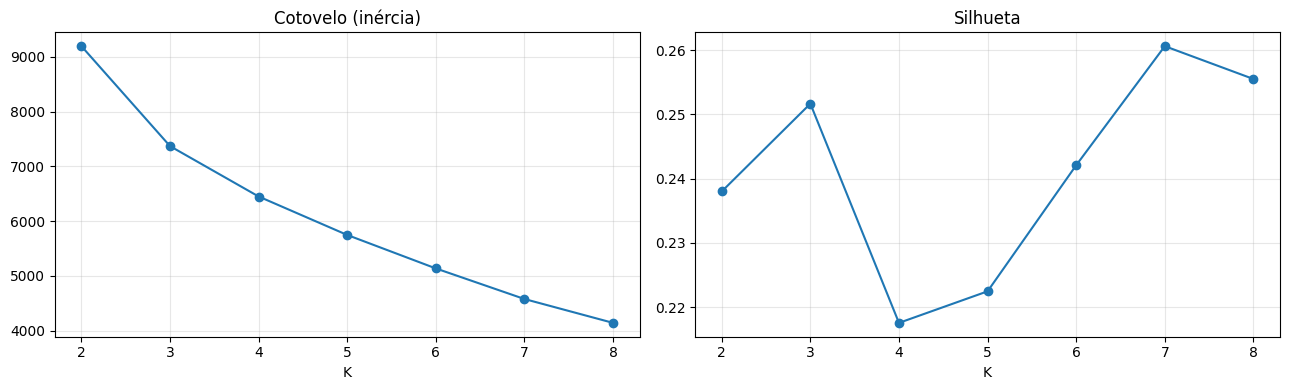

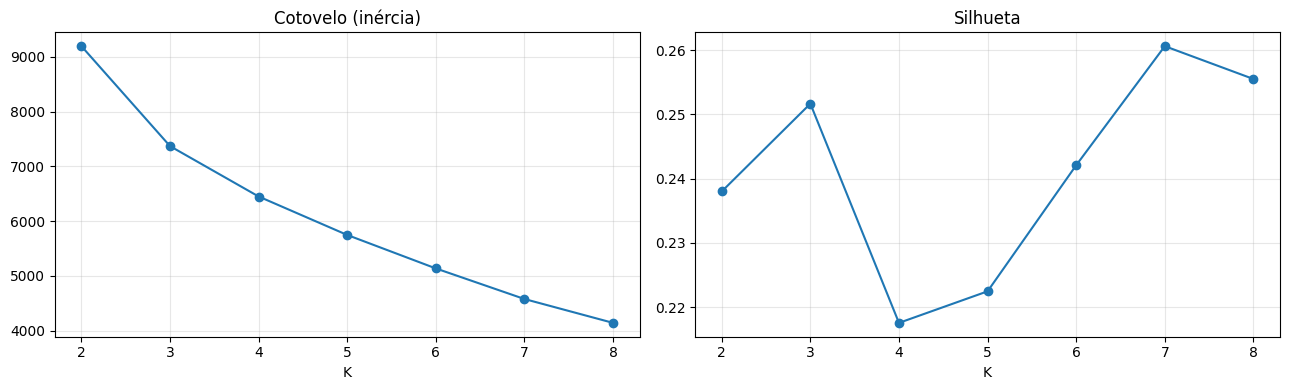

In [0]:
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

inercias, silhuetas, ks = [], [], range(2, 9)
for k in ks:
    km = KMeans(n_clusters=k, n_init=10, random_state=42).fit(Xc_scaled)
    inercias.append(km.inertia_)
    silhuetas.append(silhouette_score(Xc_scaled, km.labels_))

fig, ax = plt.subplots(1, 2, figsize=(13,4))
ax[0].plot(list(ks), inercias, marker='o'); ax[0].set_title('Cotovelo (inércia)')
ax[1].plot(list(ks), silhuetas, marker='o'); ax[1].set_title('Silhueta')
for a in ax: a.set_xlabel('K'); a.grid(alpha=.3)
plt.tight_layout(); display(fig)

In [0]:
K = 4     # ajuste conforme os gráficos acima

km = KMeans(n_clusters=K, n_init=10, random_state=42).fit(Xc_scaled)
perfil['grupo'] = km.labels_

resumo = (perfil.groupby('grupo')[FEATURES].median().round(2)
          .assign(qtd_ativos = perfil.grupo.value_counts().sort_index(),
                  pct_dos_alertas = (perfil.groupby('grupo').alertas.sum()
                                     / perfil.alertas.sum() * 100).round(1)))
display(resumo)

alertas,dias_ativos,tipos_distintos,dur_mediana,pct_sem_intervencao,pct_kpi,pct_automatico,prioridade_media,alertas_por_dia_ativo,qtd_ativos,pct_dos_alertas
92.5,45.0,11.0,979.0,0.822295,0.09159,0.9721299999999999,3.28,1.96,372,69.4
15.0,10.0,5.0,2409.5,0.2,0.28165,1.0,2.75,1.56,516,9.7
33.0,28.0,23.0,5531.0,0.0,0.87805,0.06061,2.98,1.26,99,12.4
21.0,15.0,2.0,665.0,0.93478,0.0,1.0,3.89,1.4,339,8.4


In [0]:
import mlflow
import mlflow.sklearn
from sklearn.metrics import silhouette_score

mlflow.set_experiment(f"/Users/{spark.sql('SELECT current_user()').first()[0]}/fiap_cluster_ativos")

with mlflow.start_run(run_name="kmeans_ativos"):
    mlflow.log_param("k", K)
    mlflow.log_param("n_features", len(FEATURES))
    mlflow.log_param("filtro_min_alertas", 10)
    mlflow.log_param("random_state", 42)

    mlflow.log_metric("silhouette", silhouette_score(Xc_scaled, km.labels_))
    mlflow.log_metric("n_ativos", len(perfil))

    top = (perfil.groupby('grupo').alertas.sum() / perfil.alertas.sum() * 100).max()
    mlflow.log_metric("pct_alertas_maior_grupo", round(top, 1))

    mlflow.sklearn.log_model(km, "modelo_kmeans")
    print(f"K-Means registrado: silhueta e concentração no MLflow")

2026/08/28 22:18:38 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
🔗 View Logged Model at: https://dbc-798c0991-6bbc.cloud.databricks.com/ml/experiments/2570646327148948/models/m-5494e83d300a4c2d8b948e04cbc1897a?o=2857185547527844
2026/08/28 22:18:43 INFO mlflow.models.model: Model logged without a signature. Signatures are required for Databricks UC model registry as they validate model inputs and denote the expected schema of model outputs. Please set `input_example` parameter when logging the model to auto infer the model signature. To manually set the signature, please visit https://www.mlflow.org/docs/3.8.1/ml/model/signatures.html for instructions on setting signature on models.


K-Means registrado: silhueta e concentração no MLflow


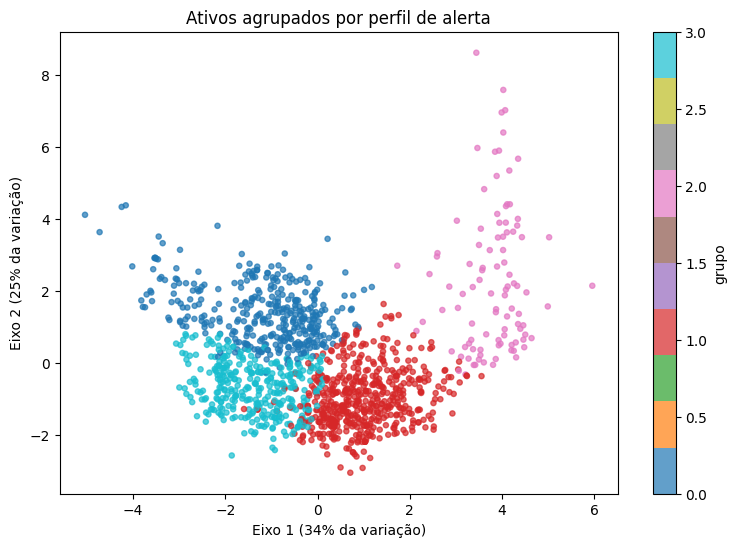

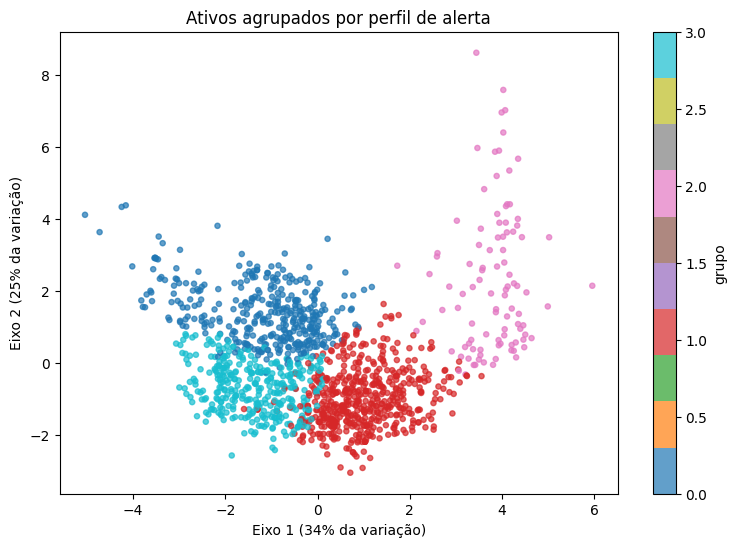

In [0]:
from sklearn.decomposition import PCA

pca = PCA(n_components=2, random_state=42)
coord = pca.fit_transform(Xc_scaled)

fig, ax = plt.subplots(figsize=(9,6))
sc = ax.scatter(coord[:,0], coord[:,1], c=perfil.grupo, cmap='tab10', s=14, alpha=.7)
ax.set_xlabel(f'Eixo 1 ({pca.explained_variance_ratio_[0]*100:.0f}% da variação)')
ax.set_ylabel(f'Eixo 2 ({pca.explained_variance_ratio_[1]*100:.0f}% da variação)')
ax.set_title('Ativos agrupados por perfil de alerta')
plt.colorbar(sc, label='grupo'); display(fig)

In [0]:
NOMES = {
    0: 'Intermitente — muitos tipos, baixa recorrência',
    1: 'Ruidoso crônico — alto volume, quase tudo sem intervenção',
    2: 'Incidente real — entra no KPI, resolução longa',
    3: 'Alarme repetitivo — poucos tipos, resolução rápida',
}
perfil['grupo_nome'] = perfil.grupo.map(NOMES)

(spark.createDataFrame(perfil.reset_index())
      .write.format("delta").mode("overwrite").option("overwriteSchema","true")
      .saveAsTable(f"{ML}.cluster_ativos"))

print("Tabela gravada em", f"{ML}.cluster_ativos")
display(perfil.groupby('grupo_nome').agg(
    ativos=('alertas','size'), alertas=('alertas','sum')).sort_values('alertas', ascending=False))

Tabela gravada em fiap_analytics.ml.cluster_ativos


ativos,alertas
372,71765
99,12869
516,10063
339,8704
